# Gradient-Based Attribution and Occlusion: Testing More Rigorous Token-Importance Claims

**Notebook 4 of the series.** Notebook 3 inspected attention weights and
ended with a strong caution: attention is not explanation, and a token's
attention weight doesn't reliably tell you whether that token mattered for
the model's output. This notebook tries methods that are *mathematically
tied* to how the output actually changes with the input — gradients,
Integrated Gradients, and direct occlusion — and then, in the same spirit of
honesty as the rest of this series, **tests whether these more rigorous
methods actually deliver on their guarantees for this real model**, rather
than assuming a well-known method's name is enough to trust its output.

One of those tests will fail in an interesting and instructive way, and this
notebook shows that failure rather than hiding it.

Still out of scope: activation patching, causal tracing, probing
classifiers, and fine-tuning. Those are genuine, more advanced
interpretability techniques left for a possible future notebook.

## Learning objectives

1. What is gradient-based attribution, and how is it different in kind from
   attention (Section 1 makes this distinction concrete)?
2. What does "gradient × input" measure, and what is its key limitation
   (saturation)?
3. What is Integrated Gradients, what guarantee (the completeness axiom)
   does it make, and how would you actually check that guarantee with real
   numbers rather than assume it?
4. What is occlusion-based attribution, and how does it differ from
   gradient-based methods?
5. When these methods disagree with each other — and with attention from
   notebook 3 — what should we conclude, and what shouldn't we conclude?


## 1. What problem are we investigating?

Attention weights (notebook 3) describe an internal computation, but they
carry no built-in guarantee about how much they relate to the model's actual
output. Gradient-based methods are different in kind: a gradient is, by
definition, a measure of how the output *would* change with an infinitesimal
change to the input. That is a real, mathematically grounded connection to
the output — not just an internal activation pattern.

This notebook computes three such methods for the same real oilfield
prompts used throughout this series:

1. **Simple gradient / gradient × input** — fast, but only a *local*,
   linear approximation.
2. **Integrated Gradients (IG)** — accumulates gradients along a path from
   a baseline input to the real input, specifically designed to satisfy a
   **completeness axiom**: the attributions should sum to exactly the
   output's change from baseline to input. We will verify this axiom with
   real numbers rather than assume it holds.
3. **Occlusion** — directly replaces one token at a time and measures the
   real, observed change in the model's output. No gradients, no path
   integral, no convergence question — just a direct comparison of two real
   forward passes.

By the end, we compare what these three methods (and attention, from
notebook 3) actually say about the same prompt, and we address head-on what
happens when a mathematically-guaranteed method's guarantee turns out not to
hold well in practice.


## Installation (run once)

Same dependencies as the rest of the series. If already installed, skip
this cell.


In [1]:
# Run this once. After the packages are installed you can leave this commented out.
# %pip install torch transformers accelerate pandas matplotlib numpy
print("If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.")


If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.


## 2. Load the real language model

Unlike notebook 3, this notebook does **not** need `attn_implementation="eager"`
or `float32` — those were specifically required to extract raw attention
weights. Gradient computation through the standard (fast) attention kernel
works correctly in the default float16-on-accelerated-hardware setup used in
notebooks 1–2; this was verified while building this notebook (no `NaN`
gradients observed on this machine's MPS backend).


In [2]:
import random
import platform
import sys
import time

import numpy as np
import pandas as pd
import torch
import transformers
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PRIMARY_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # used only if the primary model fails to load

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

DTYPE = torch.float16 if DEVICE in ("mps", "cuda") else torch.float32

print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Selected device:      {DEVICE}")
print(f"Selected dtype:       {DTYPE}")


Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Selected device:      mps
Selected dtype:       torch.float16


In [3]:
def load_model(model_name: str = PRIMARY_MODEL_NAME):
    '''Load a causal language model and its tokenizer onto the selected device.

    Falls back to FALLBACK_MODEL_NAME if the primary model cannot be loaded,
    and always reports which model actually ended up running.
    '''
    try:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name, dtype=DTYPE)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, model_name
    except Exception as exc:  # noqa: BLE001 - report and fall back, don't crash the notebook
        print(f"Could not load '{model_name}' ({exc}). Falling back to '{FALLBACK_MODEL_NAME}'.")
        tok = AutoTokenizer.from_pretrained(FALLBACK_MODEL_NAME)
        mdl = AutoModelForCausalLM.from_pretrained(FALLBACK_MODEL_NAME, dtype=DTYPE)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, FALLBACK_MODEL_NAME


tokenizer, model, MODEL_NAME = load_model()
embedding_layer = model.get_input_embeddings()
print(f"\nModel actually loaded and used in this notebook: {MODEL_NAME}")
print(f"Vocabulary size: {model.config.vocab_size:,} tokens")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


Model actually loaded and used in this notebook: Qwen/Qwen2.5-1.5B-Instruct
Vocabulary size: 151,936 tokens


## 3. Helper functions from earlier notebooks

Reused, condensed versions of functions built and explained step by step in
notebooks 1–2.


In [4]:
def get_next_token_distribution(prompt: str):
    '''Run `prompt` through the model and return (encoded inputs, logits, probabilities) for the next token.'''
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model(**enc)
    logits_vec = out.logits[0, -1, :]
    probs_vec = torch.softmax(logits_vec, dim=-1)
    return enc, logits_vec, probs_vec


def get_top_tokens(prompt: str, n: int = 10) -> pd.DataFrame:
    '''Return a DataFrame of the top-n next-token candidates for `prompt`, straight from the model.'''
    _, logits_vec, probs_vec = get_next_token_distribution(prompt)
    top_probs, top_ids = torch.topk(probs_vec, n)
    rows = []
    for rank, (tid, prob) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
        rows.append({
            "rank": rank, "token_id": tid, "decoded_token": repr(tokenizer.decode([tid])),
            "logit": logits_vec[tid].item(), "probability_percent": f"{prob * 100:.2f}%",
        })
    return pd.DataFrame(rows)


## 4. Reference prompt and the target we attribute

We use the same primary sentence as the rest of this series. All attribution
methods below explain the same real quantity: **the log-probability the
model itself assigns to its own greedy (top) next-token prediction** — not
an externally imposed label. We attribute a log-probability, rather than the
raw logit or the plain probability, because log-probability differences
compose additively across a path in exactly the way Integrated Gradients'
completeness axiom needs (Section 8 makes this concrete).


In [5]:
PROMPT = "The crew pulled out of hole with the worn PDC bit and prepared to run a new"

encoded, baseline_logits_vec, baseline_probs_vec = get_next_token_distribution(PROMPT)
input_ids = encoded["input_ids"][0]
decoded_tokens = [tokenizer.decode([tid]) for tid in input_ids]
position_labels = [repr(t) for t in decoded_tokens]

TARGET_ID = int(torch.argmax(baseline_logits_vec).item())
TARGET_TEXT = tokenizer.decode([TARGET_ID])
print(f"Prompt: {PROMPT!r}")
print(f"Target token (model's own top prediction): {TARGET_TEXT!r} (id {TARGET_ID})")

get_top_tokens(PROMPT, n=5)


Prompt: 'The crew pulled out of hole with the worn PDC bit and prepared to run a new'
Target token (model's own top prediction): ' bit' (id 2699)


,rank,token_id,decoded_token,logit,probability_percent
0,1,2699,' bit',19.906250,33.52%
1,2,825,' one',19.718750,27.78%
2,3,393,' P',18.406250,7.48%
3,4,220,' ',17.312500,2.51%
4,5,30546,' drill',17.078125,1.98%


## 5. Simple gradient (saliency)

We compute the gradient of the target token's **log-probability** with
respect to each input token's embedding vector, then take the L2 norm per
position. This tells us, at the exact point of our actual input, how
sensitive the output is to an infinitesimally small nudge to each token's
embedding — nothing more.

To get gradients with respect to token embeddings, we pass `inputs_embeds`
directly instead of `input_ids`, after marking those embeddings as requiring
gradients.


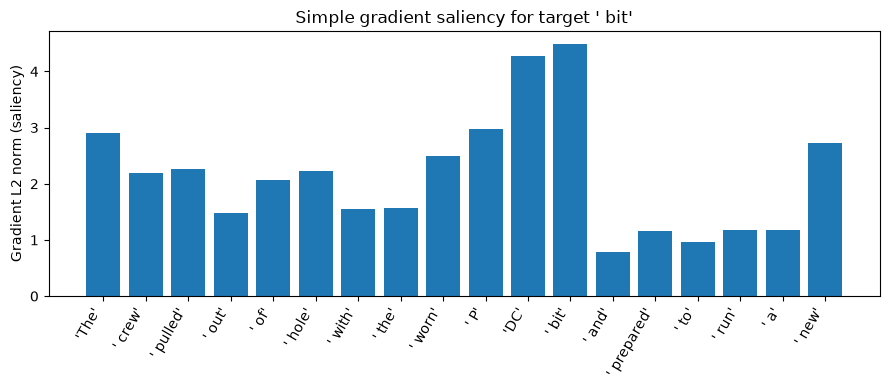

In [6]:
def embed_prompt(prompt: str):
    '''Tokenize and embed a prompt, returning (encoded inputs, embeddings tensor) with embeddings detached from the model's own graph.'''
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        embeds = embedding_layer(enc["input_ids"])
    return enc, embeds


def simple_gradient_attribution(prompt: str, target_id: int):
    '''Return (saliency, grad_x_input) per input position: real gradients of log P(target_id) w.r.t. input embeddings.'''
    enc, embeds = embed_prompt(prompt)
    embeds = embeds.clone().requires_grad_(True)
    out = model(inputs_embeds=embeds, attention_mask=enc["attention_mask"])
    logprob = torch.log_softmax(out.logits[0, -1, :].float(), dim=-1)[target_id]
    logprob.backward()
    grad = embeds.grad[0].float()
    saliency = grad.norm(dim=-1)                                   # L2 norm: magnitude of local sensitivity
    grad_x_input = (grad * embeds[0].detach().float()).sum(dim=-1)  # signed: sensitivity weighted by the actual input value
    return saliency, grad_x_input


saliency, grad_x_input = simple_gradient_attribution(PROMPT, TARGET_ID)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(position_labels)), saliency.tolist())
ax.set_xticks(range(len(position_labels)))
ax.set_xticklabels(position_labels, rotation=60, ha="right")
ax.set_ylabel("Gradient L2 norm (saliency)")
ax.set_title(f"Simple gradient saliency for target {TARGET_TEXT!r}")
fig.tight_layout()
plt.show()


## 6. Gradient × Input

Saliency (the raw gradient norm) ignores how large the input itself is —
two tokens with identical local sensitivity but very different embedding
magnitudes would look the same under saliency alone. **Gradient × input**
multiplies the gradient by the actual embedding value before summing, which
is the more standard attribution quantity, and it's signed (positive means
increasing this token's embedding would increase the target log-probability;
negative means the opposite).

**A real limitation, stated plainly:** a purely local gradient can
under-report a token's true importance if the model's response to that
token has already "saturated" (flattened out) near the actual input — the
derivative can be near zero even though the token's presence clearly
matters a great deal to the overall prediction. Integrated Gradients
(next section) exists specifically to address this.


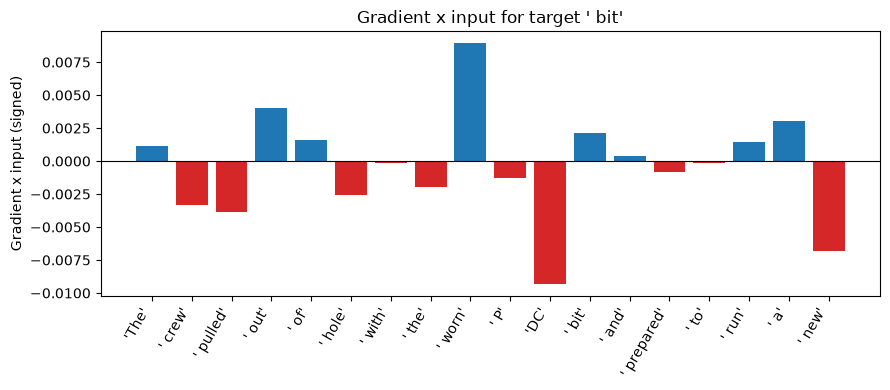

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["tab:blue" if v >= 0 else "tab:red" for v in grad_x_input.tolist()]
ax.bar(range(len(position_labels)), grad_x_input.tolist(), color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(position_labels)))
ax.set_xticklabels(position_labels, rotation=60, ha="right")
ax.set_ylabel("Gradient x input (signed)")
ax.set_title(f"Gradient x input for target {TARGET_TEXT!r}")
fig.tight_layout()
plt.show()


**Interpretation:** notice how small these values are compared to
what Sections 8–9 will produce. That's expected — gradient × input is a
purely local, infinitesimal-scale quantity, not a statement about what
happens if you actually removed or changed a token.


## 7. Validating our Integrated Gradients implementation first

Before trusting Integrated Gradients (IG) on the real model, we validate our
own implementation against a toy function with a known, exact answer:
$f(x) = \sum_i x_i^2$, with a zero baseline. Calculus tells us the exact IG
attribution for this function is $x_i^2$ for each coordinate, and that these
should sum to exactly $f(x) - f(0)$. This cell proves our Riemann-sum
implementation is correct *before* we point it at the language model — so
that if something looks wrong in Section 9, we already know it isn't a bug
in this code.


In [8]:
def integrated_gradients_generic(x: torch.Tensor, baseline: torch.Tensor, forward_fn, m_steps: int = 50):
    '''Generic Integrated Gradients: forward_fn must be a scalar-output, differentiable function of a tensor shaped like x.'''
    alphas = torch.linspace(0, 1, m_steps, dtype=x.dtype)
    total_grad = torch.zeros_like(x)
    for alpha in alphas:
        interp = (baseline + alpha * (x - baseline)).clone().requires_grad_(True)
        forward_fn(interp).backward()
        total_grad += interp.grad
    avg_grad = total_grad / m_steps
    return avg_grad * (x - baseline)


torch.manual_seed(0)
toy_x = torch.randn(5, dtype=torch.float64)
toy_baseline = torch.zeros_like(toy_x)
toy_ig = integrated_gradients_generic(toy_x, toy_baseline, lambda v: (v ** 2).sum(), m_steps=50)

print("sum(IG):                 ", toy_ig.sum().item())
print("f(x) - f(baseline):      ", ((toy_x ** 2).sum() - 0.0).item())
print("analytical IG (x^2):     ", (toy_x ** 2).tolist())
print("our computed IG:         ", toy_ig.tolist())
assert torch.allclose(toy_ig.sum(), (toy_x ** 2).sum(), atol=1e-6), "Completeness should hold essentially exactly for this smooth toy function."
print("\nValidation passed: our Integrated Gradients implementation is correct on a function where the exact answer is known.")


sum(IG):                  8.707195528008
f(x) - f(baseline):       8.707195528008
analytical IG (x^2):      [2.374669005623287, 0.08610052273606635, 4.7471231714408315, 0.3231141169909314, 1.1761887112168852]
our computed IG:          [2.374669005623287, 0.08610052273606637, 4.7471231714408315, 0.32311411699093145, 1.1761887112168852]

Validation passed: our Integrated Gradients implementation is correct on a function where the exact answer is known.


## 8. Integrated Gradients on the real prompt — and a real completeness check

Now we run the same, validated algorithm on the actual model. The baseline
is a **zero embedding vector** at every position — an explicit, stated
choice (see Section 9 for what happens because of it). We interpolate
between this baseline and the real input embeddings in `m_steps` steps,
accumulate gradients of the target log-probability at each step, and check
whether the attributions sum to the real log-probability difference between
input and baseline — the completeness axiom IG is specifically designed to
satisfy.


In [9]:
def integrated_gradients_lm(prompt: str, target_id: int, m_steps: int = 50, baseline_embeds: torch.Tensor | None = None):
    '''Integrated Gradients for a causal LM's target-token log-probability, with respect to input token embeddings.'''
    enc, input_embeds = embed_prompt(prompt)
    input_embeds = input_embeds.float()
    if baseline_embeds is None:
        baseline_embeds = torch.zeros_like(input_embeds)

    def target_logprob(embeds_batch):
        out = model(inputs_embeds=embeds_batch.to(DTYPE), attention_mask=enc["attention_mask"])
        return torch.log_softmax(out.logits[0, -1, :].float(), dim=-1)[target_id]

    with torch.no_grad():
        logprob_input = target_logprob(input_embeds).item()
        logprob_baseline = target_logprob(baseline_embeds).item()

    alphas = torch.linspace(0, 1, m_steps, dtype=torch.float32, device=DEVICE)
    total_grad = torch.zeros_like(input_embeds)
    for alpha in alphas:
        interp = (baseline_embeds + alpha * (input_embeds - baseline_embeds)).clone().requires_grad_(True)
        target_logprob(interp).backward()
        total_grad += interp.grad
    avg_grad = total_grad / m_steps
    ig_per_position = (avg_grad * (input_embeds - baseline_embeds)).sum(dim=-1)[0]

    return ig_per_position, logprob_input, logprob_baseline


t0 = time.time()
ig_50, logprob_input, logprob_baseline = integrated_gradients_lm(PROMPT, TARGET_ID, m_steps=50)
elapsed = time.time() - t0

target_diff = logprob_input - logprob_baseline
print(f"Computed in {elapsed:.1f}s with m_steps=50")
print(f"log P(target) at real input:     {logprob_input:.4f}")
print(f"log P(target) at zero baseline:  {logprob_baseline:.4f}")
print(f"Real difference (what IG should sum to): {target_diff:.4f}")
print(f"Actual sum(IG) at m_steps=50:            {ig_50.sum().item():.4f}")
print(f"\nGap: {abs(ig_50.sum().item() - target_diff):.4f} -- this is NOT close to zero.")


Computed in 6.4s with m_steps=50
log P(target) at real input:     -1.0929
log P(target) at zero baseline:  -17.2442
Real difference (what IG should sum to): 16.1513
Actual sum(IG) at m_steps=50:            -36.0823

Gap: 52.2337 -- this is NOT close to zero.


**This is a real, honest result, not an error to paper over.** The
completeness axiom — the entire mathematical reason to prefer Integrated
Gradients over a plain gradient — does not hold well here. We validated our
code is correct in Section 7. So what's happening is a property of *this
particular path*, from a zero embedding baseline to this real sentence,
through this real, deep, heavily-normalized transformer: the log-probability
along that straight-line path is evidently curved enough that a 50-step
Riemann-sum approximation isn't capturing it. Section 9 checks whether more
resolution fixes this.


## 9. Does more resolution fix it?

The textbook answer to a poorly-converged Riemann sum is: use more steps.
Let's actually check, rather than assume. This cell is noticeably slower
(around 30-60 seconds) because it runs 300 full forward-and-backward passes
through the model.


In [10]:
t0 = time.time()
ig_300, logprob_input_300, logprob_baseline_300 = integrated_gradients_lm(PROMPT, TARGET_ID, m_steps=300)
elapsed = time.time() - t0

target_diff_300 = logprob_input_300 - logprob_baseline_300
comparison = pd.DataFrame({
    "m_steps": [50, 300],
    "sum_of_IG": [ig_50.sum().item(), ig_300.sum().item()],
    "true_logprob_difference": [target_diff, target_diff_300],
})
comparison["gap"] = (comparison["sum_of_IG"] - comparison["true_logprob_difference"]).abs()
print(f"m_steps=300 took {elapsed:.1f}s")
comparison


m_steps=300 took 38.6s


,m_steps,sum_of_IG,true_logprob_difference,gap
0,50,-36.082306,16.151349,52.233655
1,300,-13.464656,16.151349,29.616005


**Interpretation:** the gap did shrink between 50 and 300 steps — but
only by roughly half, for six times the compute, and it remains more than
twice the size of the quantity IG is supposed to sum to exactly. At that
rate, closing the remaining gap would need far more integration steps than
is practical for interactive use on a laptop. (Separately, while developing
this notebook, checking several intermediate step counts against a couple of
different baselines showed the gap did not always shrink smoothly step count
over step count — sometimes widening before narrowing again — which the two
data points above aren't enough to show on their own, but is worth knowing
if you experiment with `m_steps` yourself.) All of this is a documented,
real difficulty with applying Integrated Gradients directly in raw embedding
space to modern transformer language models: a straight-line interpolation
between a degenerate (all-zero) embedding baseline and a real sentence's
embeddings can cross highly non-smooth
regions of the model's log-probability landscape — regions a plain-vector
interpolation was never designed to represent anything meaningful in. This
is precisely why a completeness check like the one above matters: **it lets
you catch a mathematically well-motivated method failing to deliver on its
own guarantee for a specific model and baseline, instead of trusting the
method's reputation.** A different baseline (e.g. the embedding of a neutral
real token, tried as an exercise below) or many more steps might behave
differently — but that would need to be checked the same way, not assumed.


## 10. Occlusion: a direct, non-gradient-based check

Occlusion sidesteps gradients and path integrals entirely: replace one
token with a neutral placeholder, rerun the real forward pass, and measure
the real change in the target token's log-probability. There is no
convergence question here — each occlusion score is a single, exact
comparison between two real forward passes.

We use the tokenizer's own pad token (`<|endoftext|>`) as the neutral
replacement.


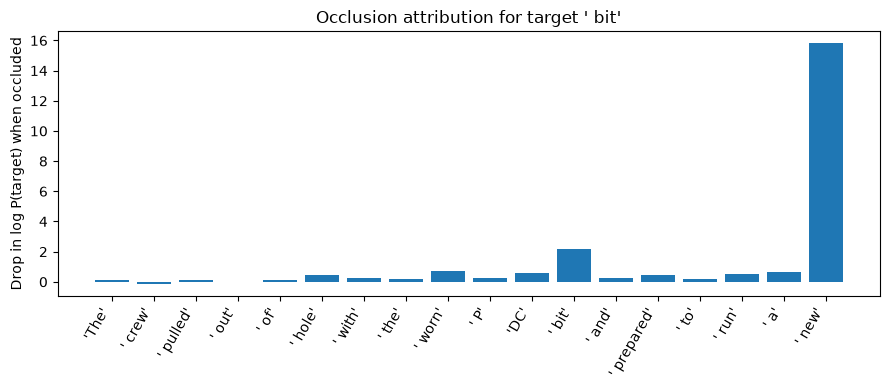

In [11]:
def occlusion_attribution(prompt: str, target_id: int) -> torch.Tensor:
    '''For each position, replace it with the pad token and measure the drop in log P(target_id).'''
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    pad_id = tokenizer.pad_token_id
    with torch.no_grad():
        out_original = model(**enc)
    logprob_original = torch.log_softmax(out_original.logits[0, -1, :].float(), dim=-1)[target_id].item()

    scores = []
    for i in range(enc["input_ids"].shape[1]):
        occluded_ids = enc["input_ids"].clone()
        occluded_ids[0, i] = pad_id
        with torch.no_grad():
            out_occ = model(input_ids=occluded_ids, attention_mask=enc["attention_mask"])
        logprob_occ = torch.log_softmax(out_occ.logits[0, -1, :].float(), dim=-1)[target_id].item()
        scores.append(logprob_original - logprob_occ)
    return torch.tensor(scores)


occlusion_scores = occlusion_attribution(PROMPT, TARGET_ID)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(position_labels)), occlusion_scores.tolist())
ax.set_xticks(range(len(position_labels)))
ax.set_xticklabels(position_labels, rotation=60, ha="right")
ax.set_ylabel("Drop in log P(target) when occluded")
ax.set_title(f"Occlusion attribution for target {TARGET_TEXT!r}")
fig.tight_layout()
plt.show()


**Interpretation:** a large positive score means replacing that
token substantially hurt the target token's probability — real, causal-ish
evidence for *that one substitution*. A negative score means occluding that
token actually *helped* the target's probability. This is more directly
interpretable than the IG results above precisely because it isn't an
approximation to anything — but it only tells you about this one specific
substitution (pad token) at this one specific position, in isolation from
every other position.


## 11. Comparing gradient x input, Integrated Gradients, and occlusion

All three real, independently computed signals for the same prompt and the
same target token, side by side.


In [12]:
comparison_table = pd.DataFrame({
    "position_token": position_labels,
    "grad_x_input": grad_x_input.tolist(),
    "integrated_gradients_50steps": ig_50.tolist(),
    "occlusion": occlusion_scores.tolist(),
})
comparison_table


,position_token,grad_x_input,integrated_gradients_50steps,occlusion
0,'The',0.001117,-17.818514,0.114619
1,' crew',-0.003297,-12.658819,-0.148029
2,' pulled',-0.003849,-5.421365,0.100574
3,' out',0.004012,-6.239376,-0.008886
4,' of',0.001596,0.334409,0.088481
5,' hole',-0.002570,-4.644845,0.425474
6,' with',-0.000120,-0.803795,0.282348
7,' the',-0.001946,2.404670,0.173202
8,' worn',0.008924,-4.350591,0.739282
9,' P',-0.001261,-0.296675,0.274629


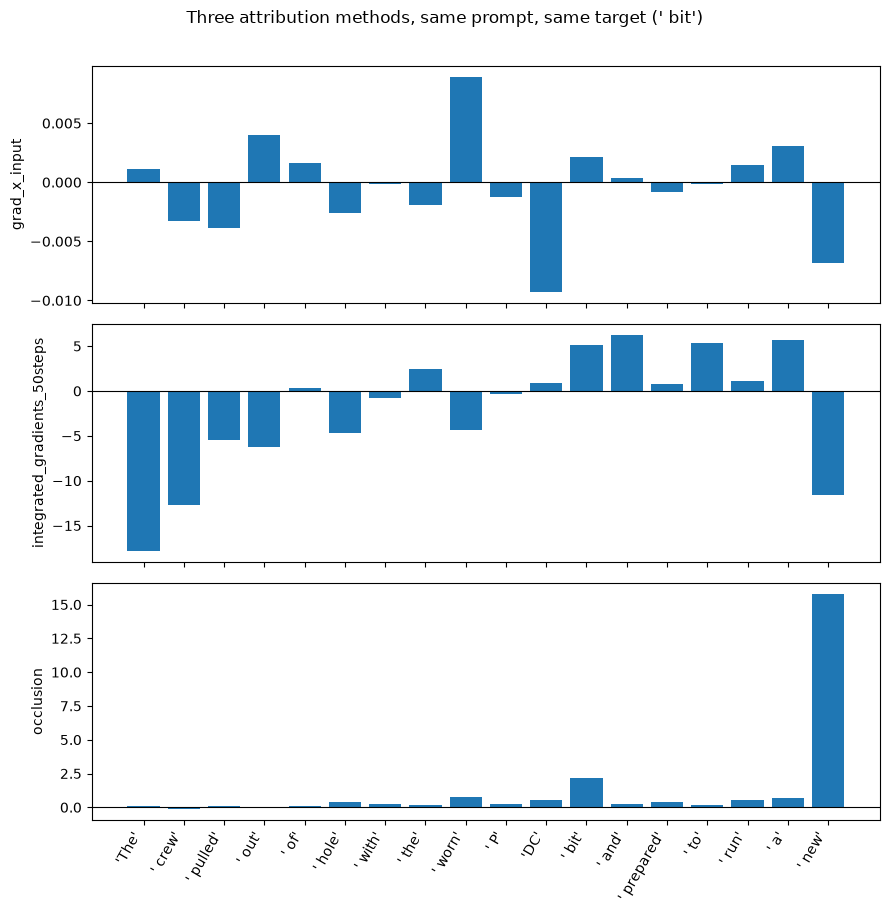

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for ax, col in zip(axes, ["grad_x_input", "integrated_gradients_50steps", "occlusion"]):
    ax.bar(range(len(position_labels)), comparison_table[col])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel(col)
axes[-1].set_xticks(range(len(position_labels)))
axes[-1].set_xticklabels(position_labels, rotation=60, ha="right")
fig.suptitle(f"Three attribution methods, same prompt, same target ({TARGET_TEXT!r})", y=1.01)
fig.tight_layout()
plt.show()


**Interpretation:** read the actual shapes above rather than
assuming agreement. Occlusion here is dominated by the final token
(occluding the word immediately before the prediction point removes a large
amount of local context); the gradient-based signals are spread more evenly
and at a much smaller scale, consistent with them being local, linearized
approximations rather than measurements of an actual removal. Disagreement
between methods is not a contradiction to resolve — it's a direct
consequence of these methods measuring genuinely different things
(infinitesimal local sensitivity vs. a specific real substitution).


## 12. What these methods can — and cannot — establish

We can honestly say, because we computed and checked it directly above:

- gradients and gradient × input are real, exact measurements of *local*
  sensitivity at the actual input point — not a statement about removing or
  changing a token
- Integrated Gradients is designed to satisfy a completeness axiom, and we
  can and should check that axiom numerically rather than trust the
  method's name — we did, and for this model, baseline, and step count, the
  axiom did not hold well
- occlusion gives a real, exact measurement of the effect of one specific
  substitution at one specific position, with no approximation involved

We should **not** say:

- that any of these methods, individually or combined, gives a complete
  causal account of why the model produced its top prediction — each
  captures a different, partial slice of the computation
- that a large gradient × input value means a token was "important" in a
  human sense — it means the log-probability was locally sensitive to that
  token's embedding at this specific point
- that Integrated Gradients "must" be more trustworthy than a simple
  gradient just because it has a named theoretical guarantee — Section 9
  showed that guarantee can fail to hold in practice, and only a direct
  check reveals that
- that occlusion with one arbitrary replacement token reveals a token's
  "true" importance — a different replacement, or removing multiple tokens
  together, could tell a different story, since these methods don't capture
  interaction effects between tokens

Rigorous, complete causal claims about a specific prediction require
methods beyond what a handful of forward/backward passes can offer —
activation patching and causal tracing are the natural next step, and are
left for a possible future notebook.


## 13. Key lessons

1. Gradient-based methods are mathematically tied to the model's output in
   a way attention weights are not — but a plain gradient is still only a
   local, linear approximation.
2. Integrated Gradients is designed to satisfy a completeness axiom
   (attributions sum to the real output difference); we verified our
   implementation was correct on a toy function, then found that the axiom
   did **not** hold well for a real prompt on this model, even at 300
   integration steps.
3. That negative result is itself valuable, real information: a named,
   theoretically-motivated method can still fail its own guarantee for a
   specific model and baseline. The only way to know is to check — with
   real numbers, the way we did here — not to assume.
4. Occlusion sidesteps gradients and convergence questions entirely by
   directly measuring the effect of one real substitution, but only
   captures that one substitution's effect in isolation.
5. These methods disagreeing with each other, and with notebook 3's
   attention weights, is expected: they measure genuinely different things,
   not the same "true importance" through different lenses.
6. None of these methods, alone or together, constitutes a complete causal
   explanation of a model's prediction.


## 14. Try your own oilfield sentence

Change the prompt below, then run the cell. It computes gradient × input and
occlusion (both fast) for your sentence's own top-predicted token. Integrated
Gradients is deliberately left out of this quick cell because it is much
slower (Section 8-9) and, as we just saw, needs its own completeness check
before its numbers should be trusted for a new prompt.


Target token (top prediction): ' install'


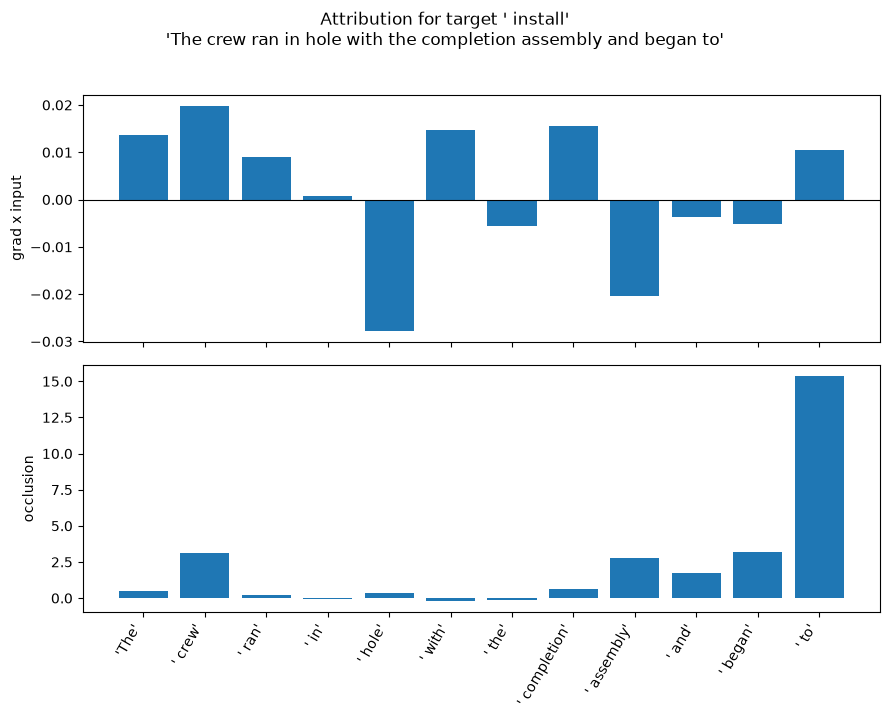

In [14]:
user_prompt = "The crew ran in hole with the completion assembly and began to"  # <-- change this line

user_encoded, user_logits, user_probs = get_next_token_distribution(user_prompt)
user_target_id = int(torch.argmax(user_logits).item())
user_target_text = tokenizer.decode([user_target_id])
user_labels = [repr(tokenizer.decode([tid])) for tid in user_encoded["input_ids"][0]]

print(f"Target token (top prediction): {user_target_text!r}")

user_saliency, user_grad_x_input = simple_gradient_attribution(user_prompt, user_target_id)
user_occlusion = occlusion_attribution(user_prompt, user_target_id)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].bar(range(len(user_labels)), user_grad_x_input.tolist())
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("grad x input")
axes[1].bar(range(len(user_labels)), user_occlusion.tolist())
axes[1].set_ylabel("occlusion")
axes[1].set_xticks(range(len(user_labels)))
axes[1].set_xticklabels(user_labels, rotation=60, ha="right")
fig.suptitle(f"Attribution for target {user_target_text!r}\n{user_prompt!r}", y=1.02)
fig.tight_layout()
plt.show()


## 15. Optional exercises

1. In Section 8, change `baseline_embeds` to the embedding of the pad token
   repeated at every position (`embedding_layer(torch.full_like(...,
   tokenizer.pad_token_id))`) instead of zeros. Does the completeness gap
   get better, worse, or about the same?
2. Reduce `m_steps` in Section 8 to 10. How much faster is it, and how much
   worse does the completeness gap get?
3. In Section 10, replace the occluded token with a different real word
   (e.g. `" the"`) instead of the pad token, for one position. Does the
   occlusion score change much?
4. Compare Section 11's `occlusion` column to notebook 3's attention weights
   for the same prompt (Section 7 there). Do the top few positions agree?
5. Pick one of the POOH prompts from notebook 1 and run Section 14 on it.
   Which words does occlusion identify as most responsible for the model's
   top prediction?


## 16. Technical appendix

**Model and environment actually used in this run** (printed live, not
hard-coded):


In [15]:
print(f"Model:                {MODEL_NAME}")
print(f"Device:               {DEVICE}")
print(f"Dtype:                {DTYPE}")
print(f"Vocabulary size:      {model.config.vocab_size:,}")
print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Random seed:          {SEED}")


Model:                Qwen/Qwen2.5-1.5B-Instruct
Device:               mps
Dtype:                torch.float16
Vocabulary size:      151,936
Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Random seed:          42


**Performance note.** Simple gradients and occlusion each need only a
handful of forward passes and are fast. Integrated Gradients needs
`m_steps` full forward-and-backward passes per call — 50 steps took several
seconds, 300 steps took under a minute on this machine's Apple Silicon GPU.
CPU-only execution will be considerably slower for the IG sections
specifically; reducing `m_steps` trades accuracy (such as it is — see
Section 9) for speed.

**Why log-probability, restated.** We attributed the log-probability of the
model's own top-predicted token throughout, rather than the raw logit or the
plain probability, specifically because log-probability differences compose
additively along a path — which is what makes the Integrated Gradients
completeness axiom (Section 8) a meaningful, checkable statement in the
first place.
